## Slade Brooks
### AEEM7063 CFD Homework 2
### 03.02.26

In [140]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Part 1

## Explicit Schemes

C:\Users\spbro\AppData\Local\Temp\ipykernel_30508\4221925478.py:55: RuntimeWarning: overflow encountered in scalar add
  error = error + (u_exact[i]-u[i])**2
C:\Users\spbro\AppData\Local\Temp\ipykernel_30508\4221925478.py:55: RuntimeWarning: overflow encountered in scalar power
  error = error + (u_exact[i]-u[i])**2
C:\Users\spbro\AppData\Local\Temp\ipykernel_30508\4221925478.py:8: RuntimeWarning: overflow encountered in scalar multiply
  return ui + v*dt/(dx**2)*(uip1 - 2*ui + uim1)
C:\Users\spbro\AppData\Local\Temp\ipykernel_30508\4221925478.py:8: RuntimeWarning: overflow encountered in scalar add
  return ui + v*dt/(dx**2)*(uip1 - 2*ui + uim1)
C:\Users\spbro\AppData\Local\Temp\ipykernel_30508\4221925478.py:8: RuntimeWarning: overflow encountered in scalar subtract
  return ui + v*dt/(dx**2)*(uip1 - 2*ui + uim1)
C:\Users\spbro\AppData\Local\Temp\ipykernel_30508\4221925478.py:8: RuntimeWarning: invalid value encountered in scalar add
  return ui + v*dt/(dx**2)*(uip1 - 2*ui + uim1)
C:\

N32_dt1024_v1 is unstable
N64_dt1024_v1 is unstable
N64_dt2048_v1 is unstable
N64_dt4096_v1 is unstable
N128_dt1024_v1 is unstable
N128_dt2048_v1 is unstable
N128_dt4096_v1 is unstable
N128_dt8192_v1 is unstable
N32_dt1024_v2 is unstable
N32_dt2048_v2 is unstable
N64_dt1024_v2 is unstable
N64_dt2048_v2 is unstable
N64_dt4096_v2 is unstable
N64_dt8192_v2 is unstable


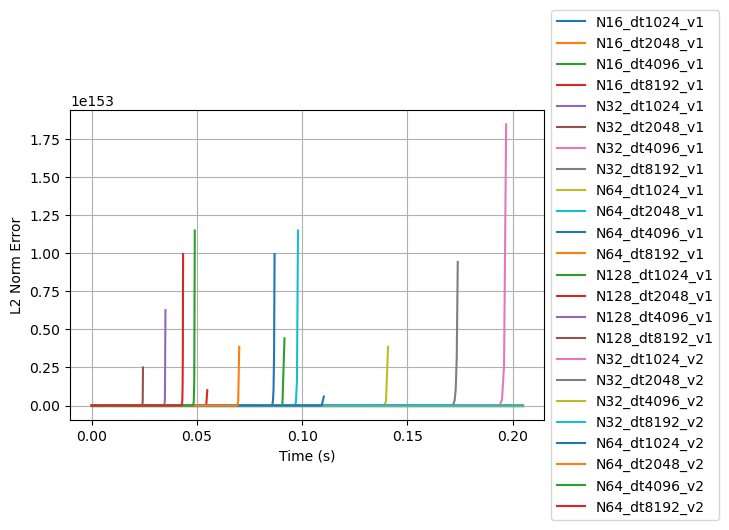

In [141]:
# Initial condition: Sine profile (Option-3)
def initial_conditions_sine(x, L):
    u0 = np.sin(2*np.pi*x/L)
    return(u0)

# ftcs for pde3
def ftcs_3(ui, uip1, uim1, uim2, dx, dt, v):
    return ui + v*dt/(dx**2)*(uip1 - 2*ui + uim1)

# create fxn for pde3
def pde3(v, nx, L, dt, nt, ics, fd, fdstr):
    # Setup the grid
    x = np.linspace(0, L, nx)
    dx = L / nx

    # Point to the initial condition you want to use
    initial_conditions = ics

    # Set initial conditions
    u0 = initial_conditions(x, L)

    # Set up the solution array u
    u = u0.copy()

    # Set up the exact solution for reference
    u_exact = u0.copy()

    # Store solution at each time step
    us = [u.copy()]

    # Store exact solution at each time step
    u_exacts = [u_exact.copy()]

    # Save L2 norm errors in an array
    errors = []

    time = 0.0
    for n in range(nt):
        time = time + dt
        # Numerical solution update
        u_new = u.copy()  
        for i in range(1, nx-1):
            # update with fd model
            u_new[i] = fd(u[i], u[i+1], u[i-1], u[i-2], dx, dt, v)
        u = u_new.copy()
        us.append(u.copy())
        
        # Exact solution update
        u_exact = np.sin(2*np.pi*x/L)*np.exp(-v*(2*np.pi/L)**2*time)
        u_exacts.append(u_exact.copy())
        
        # Calculate L2 norm error between numerical and exact solution
        error = 0.0
        for i in range(1,nx-1):
            error = error + (u_exact[i]-u[i])**2
        error = np.sqrt(error/(nx-2))
        errors.append(error)
    
    return x, us, u_exacts, errors

# Parameters
L = 1.0          # Length of domain

# list of nxs to use
nxs = np.array([16, 32, 64, 128])

# list of dts to use
dts = np.array([1/1024., 1/2048., 1/4096., 1/8192.])

# run for each differencing option (first for v=1)
v = 1.
us = {}
xs = {}
errs = {}
for nx in nxs:
    for dt in dts:
        # determine nt to run 1s
        nt = int(.2048/dt)
        
        # run ft-bs
        x, usftbs, uexacts, errorsftbs = pde3(v, nx, L, dt, nt, initial_conditions_sine, ftcs_3, "ftcs")
        
        # store soltn in dict
        us[f"N{nx:.0f}_dt{1/dt:.0f}_v{v:.0f}"] = usftbs
        xs[f"N{nx:.0f}_dt{1/dt:.0f}_v{v:.0f}"] = x
        errs[f"N{nx:.0f}_dt{1/dt:.0f}_v{v:.0f}"] = np.array([np.linspace(0., 0.2048, len(errorsftbs)), errorsftbs])
        
# now run for v=2
v = 2.
nxs = np.array([32, 64])
for nx in nxs:
    for dt in dts:
        # determine nt to run 1s
        nt = int(.2048/dt)
        
        # run ft-bs
        x, usftbs, uexacts, errorsftbs = pde3(v, nx, L, dt, nt, initial_conditions_sine, ftcs_3, "ftcs")
        
        # store soltn in dict
        us[f"N{nx:.0f}_dt{1/dt:.0f}_v{v:.0f}"] = usftbs
        xs[f"N{nx:.0f}_dt{1/dt:.0f}_v{v:.0f}"] = x
        errs[f"N{nx:.0f}_dt{1/dt:.0f}_v{v:.0f}"] = np.array([np.linspace(0., 0.2048, len(errorsftbs)), errorsftbs])
        
# plot errors for each one to see if they're blowing up
plt.figure()
ax=plt.subplot(111)
for key in errs:
    # plot each of the errors over time
    ax.plot(errs[key][0], errs[key][1], label=f"{key}")
    
    # find any that have exploding errors and report them
    if errs[key][1][-1] > 10 or np.isnan(errs[key][1][-1]) == True:
        print(f"{key} is unstable")

# place legend outside
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel("Time (s)"); plt.ylabel("L2 Norm Error")
# plt.ylim(0, 1000)
plt.grid(); plt.tight_layout()

## Implicit Schemes

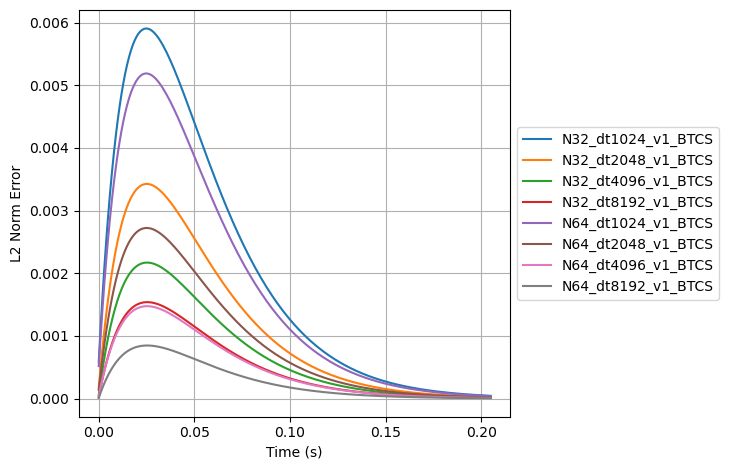

In [142]:
def BTCSpde3(nx, dt, nu):
    dx = L / (nx - 1)
    nt = int(.2048/dt)

    # Setup the grid
    x = np.linspace(0, L, nx)

    # Set initial conditions
    u0 = initial_conditions_sine(x, L)

    # Set up the solution array u
    u = u0.copy()

    # Set up the exact solution for reference
    u_exact = u0.copy()

    # Store solution at each time step
    us = [u.copy()]

    # Store exact solution at each time step
    u_exacts = [u_exact.copy()]

    # Save L2 norm errors in an array
    errors = []

    # Matrix parameter
    s = nu * dt / dx**2

    # Construct the matrix
    # A * u^{n+1} = B * u^n
    A = np.zeros((nx, nx))
    B = np.zeros((nx, nx))

    # Interior points
    for i in range(1, nx-1):
        # write in the line for each row of A and B (from notes)
        A[i, (i-1):(i-1)+3] = np.array([s, -(1 + 2*s), s])
        B[i, i] = -1
    
    # Boundary conditions (Set u=0 and don't udpate anything for the boundaries)
    A[0, 0] = 1
    A[-1, -1] = 1
    B[0, 0] = 1
    B[-1, -1] = 1

    time = 0.0
    for n in range(nt):
        time = time + dt
        # Numerical solution update
        u_new = u.copy()
        # Multiply the RHS matrix
        b = B @ u
        # Solve the linear system
        u_new = np.linalg.solve(A, b)
        # Update the solution
        u = u_new.copy()
        us.append(u.copy())
        
        # Exact solution update
        u_exact = initial_conditions_sine(x, L) * np.exp(-nu * (2*np.pi/L)**2 * time)
        u_exacts.append(u_exact.copy())
        
        # Calculate L2 norm error between numerical and exact solution
        error = 0.0
        for i in range(1,nx-1):
            error = error + (u_exact[i]-u[i])**2
        error = np.sqrt(error/(nx-2))
        errors.append(error)
        
    return us, u_exacts, errors

# parameters
L = 1.0          # Length of domain
nu = 1.

# list of nxs to use
nxs = np.array([32, 64])

# list of dts to use
dts = np.array([1/1024., 1/2048., 1/4096., 1/8192.])

# run for each set of inputs
us = {}
xs = {}
errs = {}
for nx in nxs:
    for dt in dts:
        # determine nt to run 1s
        nt = int(.2048/dt)
        
        # run bt-cs
        usbtcs, uexacts, errorsbtcs = BTCSpde3(nx, dt, nu)
        
        # store soltn in dict
        us[f"N{nx:.0f}_dt{1/dt:.0f}_v{nu:.0f}"] = usbtcs
        errs[f"N{nx:.0f}_dt{1/dt:.0f}_v{nu:.0f}_BTCS"] = np.array([np.linspace(0., 0.2048, len(errorsbtcs)), errorsbtcs])
        
# plot errors for each one to see if they're blowing up
plt.figure()
ax=plt.subplot(111)
for key in errs:
    # plot each of the errors over time
    ax.plot(errs[key][0], errs[key][1], label=f"{key}")
    
    # find any that have exploding errors and report them
    if errs[key][1][-1] > 10 or np.isnan(errs[key][1][-1]) == True:
        print(f"{key} is unstable")

# place legend outside
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel("Time (s)"); plt.ylabel("L2 Norm Error")
# plt.ylim(0, 1000)
plt.grid(); plt.tight_layout()

## Discussion

|                 | 1/1024 | 1/2048 | 1/4096 | 1/8192 |
|-----------------|--------|--------|--------|--------|
| N=16, v=1       | N      | N      | N      | N      |
| N=32, v=1       | Y      | N      | N      | N      |
| N=64, v=1       | Y      | Y      | Y      | N      |
| N=128, v=1      | Y      | Y      | Y      | Y      |
| N=32, v=2       | Y      | Y      | N      | N      |
| N=64, v=2       | Y      | Y      | Y      | Y      |
| N=32, v=1, BTCS | N      | N      | N      | N      |
| N=64, v=1, BTCS | N      | N      | N      | N      |

The results seen above make sense based on the CFL number. For the heat equation:
$$
\begin{equation*}
CFL = \nu\frac{\Delta t}{\Delta x^2} \leq \frac{1}{2}
\end{equation*}
$$
The CFL will be increased with larger time steps (moving left on the table) and will be increased with smaller space
steps (moving down on the table). We can see that our results match this trend. Decreasing the time step for a given
grid resolution leads to stable cases, as evidenced by N=32, v=1, FTCS being stable for time steps of 1/2048 or smaller
(and a similar trend for N=64). We can see as well that moving down the table in increasing number of spatial points (so
a smaller space step), things become less stable. For a time step of 1/2048, the FTCS begins to blow up at N=64, but is
stable for N=16 and N=32. Doubling the value of $\nu$ also causes worse stability, since it doubles the CFL number. We
can see for 1/2048, N=32, v=1, the scheme is stable and has a CFL number of 0.5. When $\nu$ is set to 2, this becomes a
CFL of 1 which violates the stability criteria for the CFL and therefore is unstable. However, with a timestep that is
half the size (1/4096), doubling $\nu$ does not make the scheme unstable since it will be increasing from 0.25 to 0.5
and still satisfies the stability criteria. Lastly, we see that all of the implicit schemes are stable. This is expected
since the heat equation is a parabolic PDE. This means information propagates at infinite speed and thus requires both
initial conditions and boundary conditions for a correct solution. This requires an implicit scheme to be
unconditionally stable, which is reflected in the results.

# Part 2a

$$
\begin{align*}
    u_t=vu_{xx} \rightarrow u_{tt}=v^2u_{xxxx}
\end{align*}
\\
\begin{align*}
    \frac{u_i^{n+1}-u_i^n}{\Delta t}-v\frac{u_{i+1}^n-2u_i^n+u_{i-1}^n}{\Delta x^2} =0 \\ \\
    \frac{u_i^{n+1}-u_i^n}{\Delta t}=u_t + u_{tt}\frac{\Delta t}{2!} + u_{ttt}\frac{\Delta t^2}{3!}+\cdots
\end{align*}
\\
\begin{align*}
    -v\frac{u_{i+1}^n-2u_i^n+u_{i-1}^n}{\Delta x^2}&=-\frac{v}{\Delta x^2}(u + u_x\frac{\Delta x}{1!} +
    u_{xx}\frac{\Delta x^2}{2!} + u_{xxx}\frac{\Delta x^3}{3!} + u_{xxxx}\frac{\Delta x^4}{4!} + \cdots \\
    &-2u + u -u_x\frac{\Delta x}{1!} + u_{xx}\frac{\Delta x^2}{2!} - u_{xxx}\frac{\Delta x^3}{3!} +
    u_{xxxx}\frac{\Delta x^4}{4!} + \cdots) \\ \\
    &=-\frac{v}{\Delta x^2}\left(u_{xx}\frac{2\Delta x^2}{2!} + u_{xxxx}\frac{2\Delta x^4}{4!} + \cdots\right)=
    -v\left(u_{xx} + u_{xxxx}\frac{2\Delta x^2}{4!} + \cdots\right)
\end{align*}
\\
\begin{align*}
    u_t + u_{tt}\frac{\Delta t}{2!} + u_{ttt}\frac{\Delta t^2}{3!}+\cdots &=v\left(u_{xx} +
    u_{xxxx}\frac{2\Delta x^2}{4!} +\cdots\right) \\ \\
    u_t + v^2u_{xxxx}\frac{\Delta t}{2!} + u_{ttt}\frac{\Delta t^2}{3!} &= v\left(u_{xx} +
    u_{xxxx}\frac{2\Delta x^2}{4!}\right) \\ \\
    u_t - vu_{xx} + u_{ttt}\frac{\Delta t^2}{3!}&=vu_{xxxx}\frac{2\Delta x^2}{4!}-v^2u_{xxxx}\frac{\Delta t}{2!} \\ \\
    u_t - vu_{xx} + u_{ttt}\frac{\Delta t^2}{3!}&=\left(v\frac{2\Delta x^2}{4!}-v^2\frac{\Delta t}{2!}\right)u_{xxxx}
\end{align*}
\\
\begin{align*}
    CFL=v\frac{\Delta t}{\Delta x^2}\rightarrow \Delta t=CFL\frac{\Delta x^2}{v} \\ \\
    u_t - vu_{xx} + u_{ttt}\frac{\Delta t^2}{3!}=\left(v\frac{2\Delta x^2}{4!}-v\frac{CFL\Delta x^2}{2!}\right)u_{xxxx} \\ \\
    u_t - vu_{xx} + u_{ttt}\frac{\Delta t^2}{3!}=v\Delta x^2\left(\frac{2}{4!}-\frac{CFL}{2}\right)u_{xxxx} \\ \\
    u_t - vu_{xx} + u_{ttt}\frac{\Delta t^2}{3!}-\frac{v\Delta x^2}{2}\left(\frac{4}{4!}-CFL\right)u_{xxxx}=0 \\ \\
    \fbox{$u_t - vu_{xx} -\frac{v\Delta x^2}{12}\left(1-6CFL\right)u_{xxxx} + TE + HOT=0$}
\end{align*}
$$

# Part 2b

To be positive diffusivity on the RHS, the coefficient of the hyperviscosity must be negative on the LHS. Since it
already has a negative coefficient, the term inside the parentheses containing the CFL must be positive, otherwise the
sign flips and it will cause instability. Thus:
$$
\begin{align*}
    1-6CFL \geq 0 \\
    -6CFL \geq -1 \\
    CFL \leq \frac{1}{6}
\end{align*}
$$
If this condition is satisfied, then the coefficient will be positive (or 0), leaving the $u_{xxxx}$ coefficient
negative on the LHS, giving positive diffusivity when moved to the RHS and thus stable solutions.